In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_parquet('../data/processed/train_features.parquet')

print(f"Загружено строк: {len(df):,}")

Загружено строк: 40,618,962


Нам нужно оставить только те колонки, которые реально помогают предсказывать.


Мы оставляем только те данные, которые известны нам в момент рекомендации, до того как пользователь нажал кнопку «Play». Это те самые характеристики, которые помогут модели догадаться, какой будет досмотр.

In [4]:
#Список колонок, которые мы НЕ берем в модель
drop_cols = [
    'user_id', 'item_id', 'author_id',
    'target', 'timespent',
    'train_interactions_rank_x', 'train_interactions_rank_y', # служебный мусор
    'author_mean_target', 'user_mean_target' # Дубликаты (у меня есть avg_target)
]

features = [c for c in df.columns if c not in drop_cols]

print(f"Используем {len(features)} признаков для обучения.")
print(features)

Используем 23 признаков для обучения.
['place', 'platform', 'agent', 'like', 'dislike', 'share', 'bookmark', 'click_on_author', 'open_comments', 'duration', 'age', 'gender', 'geo', 'author_video_count', 'user_watch_count', 'engagement_score', 'author_avg_target', 'author_avg_engagement', 'author_popularity', 'user_avg_target', 'user_avg_engagement', 'user_activity', 'video_duration_type']


берем 5 миллионов строк и делим их на 80% (обучение) и 20% (проверка)

In [5]:
from sklearn.model_selection import train_test_split

df_sample = df.sample(n=5000000, random_state=42)

X = df_sample[features]
y = df_sample['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#удаляем df_sample чтоб освободить RAM
import gc
del df_sample
gc.collect()

print(f"Обучающая выборка: {X_train.shape[0]:,} строк")
print(f"Тестовая выборка: {X_test.shape[0]:,} строк")

Обучающая выборка: 4,000,000 строк
Тестовая выборка: 1,000,000 строк


Baseline — Линейная Регрессия

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_base = model_lr.predict(X_test)
y_pred_base = np.clip(y_pred_base, 0, 1)

mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print(f"LINEAR REGRESSION РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_base:.4f}")
print(f"MSE:  {mse_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")
print(f"R2:   {r2_base:.4f}")

LINEAR REGRESSION РЕЗУЛЬТАТЫ
MAE:  0.3109
MSE:  0.1268
RMSE: 0.3561
R2:   0.2374


In [7]:
import joblib

model_path_lr = '../models/linear_regression_v1.pkl'
joblib.dump(model_lr, model_path_lr)

print(f"Модель Baseline сохранена по пути: {model_path_lr}")

Модель Baseline сохранена по пути: ../models/linear_regression_v1.pkl


Цифра MAE: 0.3109 говорит нам о том, что в среднем простая линейная модель ошибается на 31% при предсказании досмотра видео.

LightGBM

In [8]:
!pip install lightgbm

In [9]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Обучение LightGBM...")
lgb_model = LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=10,
    random_state=42, n_jobs=-1, importance_type='gain'
)

lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='mae')

y_pred_lgb = np.clip(lgb_model.predict(X_test), 0, 1)

# Расчет метрик
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"\nLIGHTGBM РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_lgb:.4f}")
print(f"MSE:  {mse_lgb:.4f}")
print(f"RMSE: {rmse_lgb:.4f}")
print(f"R2:   {r2_lgb:.4f}")
print(f"Улучшение MAE к Baseline: {((0.3109 - mae_lgb) / 0.3109) * 100:.2f}%")

Обучение LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136890 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2411
[LightGBM] [Info] Number of data points in the train set: 4000000, number of used features: 23
[LightGBM] [Info] Start training from score 0.526714

LIGHTGBM РЕЗУЛЬТАТЫ
MAE:  0.2993
MSE:  0.1215
RMSE: 0.3486
R2:   0.2694
Улучшение MAE к Baseline: 3.75%


узнаем, на что модель опиралась при принятии решений.

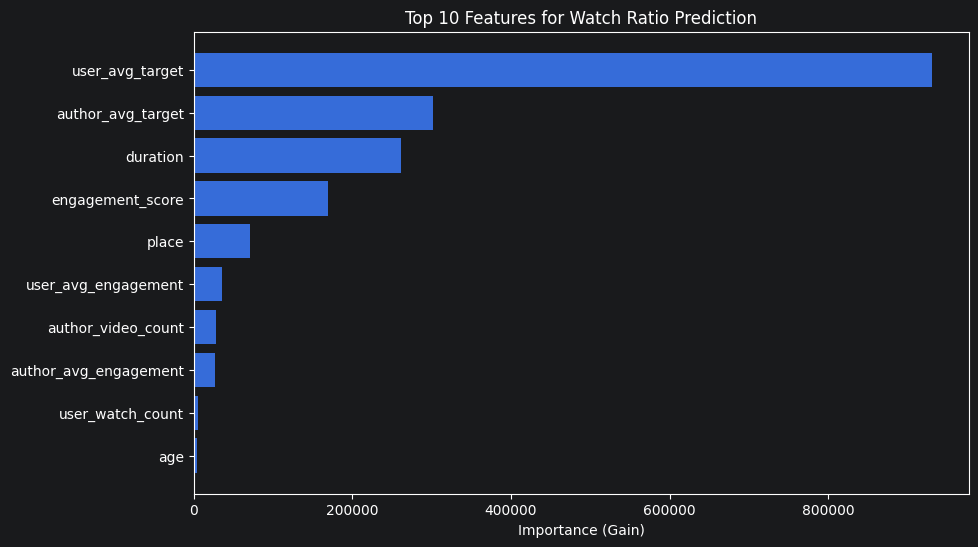

Топ-5 самых важных признаков:
              feature     importance
19    user_avg_target  930664.580063
16  author_avg_target  301435.390337
9            duration  261900.344289
15   engagement_score  169911.432837
0               place   70750.703440


In [10]:
importances = pd.DataFrame({
    'feature': features,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel('Importance (Gain)')
plt.title('Top 10 Features for Watch Ratio Prediction')
plt.gca().invert_yaxis()
plt.show()

print("Топ-5 самых важных признаков:")
print(importances.head(5))

Модель поняла самое главное — зритель важнее контента. Если человек привык досматривать видео до конца, он, скорее всего, досмотрит и это. Это мощнейший признак, который тащит на себе весь прогноз.

Помимо всего этого в топе у нас:

Качество автора и длина ролика

Наш созданный признак engagment_score вошел тоже в топ - это значит что модель активно использует лайки/репосты для уточнения прогноза.


In [11]:
model_path = '../models/lightgbm_v1.pkl'
joblib.dump(lgb_model, model_path)

print(f"Модель сохранена по пути: {model_path}")

Модель сохранена по пути: ../models/lightgbm_v1.pkl


XGBoost

In [12]:
!pip install xgboost

In [13]:
from xgboost import XGBRegressor

print("Обучение XGBoost...")
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method='hist', n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, 1)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBOOST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_xgb:.4f}")
print(f"MSE:  {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2:   {r2_xgb:.4f}")

Обучение XGBoost...

XGBOOST РЕЗУЛЬТАТЫ
MAE:  0.2994
MSE:  0.1217
RMSE: 0.3488
R2:   0.2684


In [14]:
model_path_xgb = '../models/xgboost_v1.pkl'
joblib.dump(xgb_model, model_path_xgb)

print(f"Модель XGBoost сохранена по пути: {model_path_xgb}")

Модель XGBoost сохранена по пути: ../models/xgboost_v1.pkl


CatBoost

In [15]:
!pip install catboost

In [16]:
from catboost import CatBoostRegressor

print("Обучение CatBoost...")
cat_model = CatBoostRegressor(iterations=300, learning_rate=0.1, depth=6, silent=True, thread_count=-1)
cat_model.fit(X_train, y_train)

y_pred_cat = np.clip(cat_model.predict(X_test), 0, 1)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"\nCATBOOST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_cat:.4f}")
print(f"MSE:  {mse_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"R2:   {r2_cat:.4f}")

Обучение CatBoost...

CATBOOST РЕЗУЛЬТАТЫ
MAE:  0.3011
MSE:  0.1223
RMSE: 0.3498
R2:   0.2644


In [17]:
model_path_cat = '../models/catboost_v1.pkl'
joblib.dump(cat_model, model_path_cat)

print(f"Модель CatBoost сохранена по пути: {model_path_cat}")

Модель CatBoost сохранена по пути: ../models/catboost_v1.pkl


Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

print("Обучение Random Forest (c ограниченной выборка для экономии RAM у меня уже пк устал :) )...")
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = np.clip(rf_model.predict(X_test), 0, 1)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRANDOM FOREST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

Обучение Random Forest (c ограниченной выборка для экономии RAM у меня уже пк устал :) )...

RANDOM FOREST РЕЗУЛЬТАТЫ
MAE:  0.3060
MSE:  0.1248
RMSE: 0.3533
R2:   0.2494


In [19]:
model_path_rf = '../models/random_forest_v1.pkl'
joblib.dump(rf_model, model_path_rf)

print(f"Модель Random Forest сохранена по пути: {model_path_rf}")

Модель Random Forest сохранена по пути: ../models/random_forest_v1.pkl


Ансамбль (LGBM + XGB + Cat)

In [20]:
print("Создание ансамбля (LGBM + XGB + Cat)")
y_pred_ensemble = (y_pred_lgb + y_pred_xgb + y_pred_cat) / 3

mae_ens = mean_absolute_error(y_test, y_pred_ensemble)
mse_ens = mean_squared_error(y_test, y_pred_ensemble)
rmse_ens = np.sqrt(mse_ens)
r2_ens = r2_score(y_test, y_pred_ensemble)

print(f"\nENSEMBLE РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_ens:.4f}")
print(f"MSE:  {mse_ens:.4f}")
print(f"RMSE: {rmse_ens:.4f}")
print(f"R2:   {r2_ens:.4f}")

Создание ансамбля (LGBM + XGB + Cat)

ENSEMBLE РЕЗУЛЬТАТЫ
MAE:  0.2999
MSE:  0.1217
RMSE: 0.3489
R2:   0.2682


Сделаем общий вывод

In [21]:
import pandas as pd

final_data = [
    {
        'Model': 'Linear Regression (Baseline)',
        'MAE': mae_base,
        'MSE': mse_base,
        'RMSE': rmse_base,
        'R2': r2_base
    },
    {
        'Model': 'Random Forest',
        'MAE': mae_rf,
        'MSE': mse_rf,
        'RMSE': rmse_rf,
        'R2': r2_rf
    },
    {
        'Model': 'XGBoost',
        'MAE': mae_xgb,
        'MSE': mse_xgb,
        'RMSE': rmse_xgb,
        'R2': r2_xgb
    },
    {
        'Model': 'CatBoost',
        'MAE': mae_cat,
        'MSE': mse_cat,
        'RMSE': rmse_cat,
        'R2': r2_cat
    },
    {
        'Model': 'LightGBM',
        'MAE': mae_lgb,
        'MSE': mse_lgb,
        'RMSE': rmse_lgb,
        'R2': r2_lgb
    },
    {
        'Model': 'Ensemble (LGBM+XGB+Cat)',
        'MAE': mae_ens,
        'MSE': mse_ens,
        'RMSE': rmse_ens,
        'R2': r2_ens
    }
]


df_results = pd.DataFrame(final_data)
baseline_mae_val = df_results.loc[df_results['Model'] == 'Linear Regression (Baseline)', 'MAE'].values[0]

df_results['Improvement %'] = ((baseline_mae_val - df_results['MAE']) / baseline_mae_val * 100).round(2)

# Сортируем таблицу по MAE
df_results = df_results.sort_values(by='MAE').reset_index(drop=True)

print("ФИНАЛЬНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
display(df_results)

df_results.to_csv('../data/processed/model_comparison.csv', index=False)

ФИНАЛЬНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ


,Model,MAE,MSE,RMSE,R2,Improvement %
0,LightGBM,0.299252,0.121516,0.348591,0.269381,3.75
1,XGBoost,0.299435,0.121680,0.348826,0.268396,3.69
2,Ensemble (LGBM+XGB+Cat),0.299851,0.121707,0.348865,0.268234,3.55
3,CatBoost,0.301120,0.122348,0.349782,0.264380,3.14
4,Random Forest,0.306038,0.124847,0.353337,0.249350,1.56
5,Linear Regression (Baseline),0.310897,0.126827,0.356128,0.237448,0.00


Для дальнейшего тестирования выгрузим наши данные 5 лямов для тестов

In [22]:
X_test.to_parquet('../data/future_testing/X_test_final.parquet')
pd.DataFrame(y_test).to_parquet('../data/future_testing/y_test_final.parquet')